# Model Building and Evaluation

This notebook trains Machine Learning models to predict sales and evaluates their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

## Load Processed Data

In [2]:
train_df = pd.read_csv("processed_train.csv")
test_df = pd.read_csv("processed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (844392, 19)
Test shape: (35104, 19)


## Define Evaluation Metric (RMSPE)
Root Mean Squared Percentage Error.

In [3]:
def rmspe(y, yhat):
    return np.sqrt(np.mean(((y - yhat) / y) ** 2))

## Prepare Data for Modeling

In [4]:
# Define features and target
X = train_df.drop(['Sales', 'Revenue', 'Customers', 'Id'], axis=1, errors='ignore') # Drop target, Id, and other non-features
y = np.log1p(train_df['Sales']) # Log transform target

# Ensure test_df has same columns
# Remove 'Id' from test features for prediction, but keep it for submission
test_ids = test_df['Id']
X_test_predict = test_df.drop(['Id', 'Date', 'Sales', 'Revenue', 'Customers'], axis=1, errors='ignore')

# Align columns
X_test_predict = X_test_predict[X.columns]

# Split Train/Val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

Training Shape: (675513, 18)
Validation Shape: (168879, 18)


## 1. Linear Regression

In [ ]:
lreg = LinearRegression()
lreg.fit(X_train, y_train)

y_pred_lreg = lreg.predict(X_val)
error_lreg = rmspe(np.expm1(y_val), np.expm1(y_pred_lreg))
print("Linear Regression RMSPE:", error_lreg)

## 2. Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1) # Reduced estimators for speed
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
error_rf = rmspe(np.expm1(y_val), np.expm1(y_pred_rf))
print("Random Forest RMSPE:", error_rf)

Random Forest RMSPE: 0.1431799759573044


### Feature Importance (Random Forest)

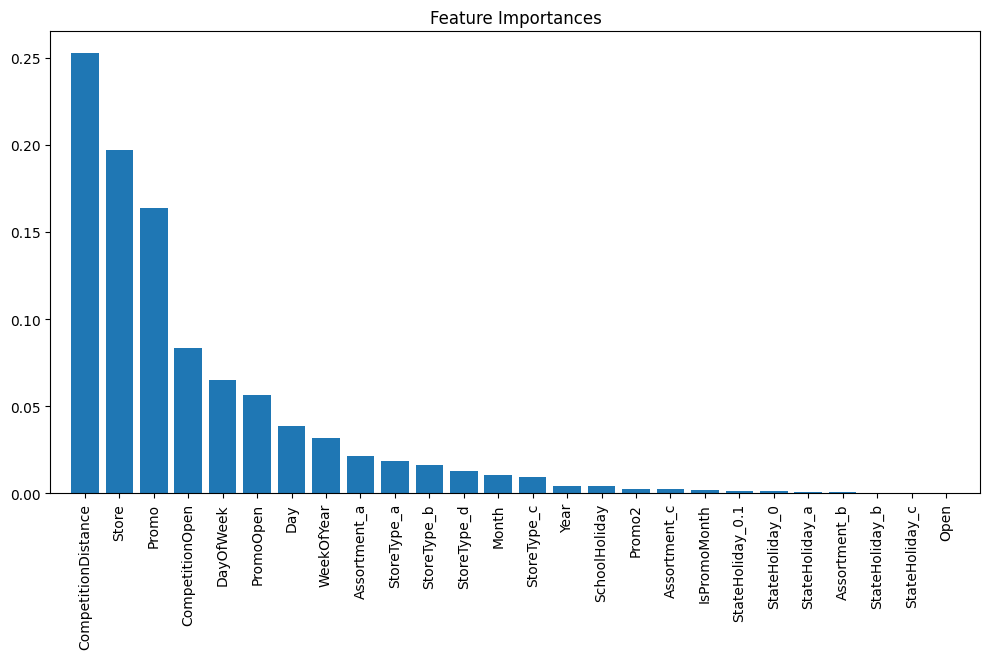

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

## 3. Gradient Boosting (sklearn)

In [ ]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42, verbose=1)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)
error_gb = rmspe(np.expm1(y_val), np.expm1(y_pred_gb))
print("Gradient Boosting RMSPE:", error_gb)

      Iter       Train Loss   Remaining Time 


         1           0.1714            2.92m


         2           0.1639            2.64m


         3           0.1575            2.52m


         4           0.1521            2.46m


...

        70           0.0919           47.56s


        80           0.0883           31.09s


        90           0.0849           15.29s


       100           0.0803            0.00s


Gradient Boosting RMSPE: 0.321413436548261


## Final Submission
Generating submission using the best model.

In [ ]:
# Predict on Test Set
# Use the best model (e.g., Random Forest or Gradient Boosting)
best_model = rf 
test_probs = best_model.predict(X_test_predict)
real_pred = np.expm1(test_probs)

# Create Submission File
submission = pd.DataFrame({"Id": test_ids, "Sales": real_pred})
submission.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv")

Submission saved to submission.csv
